In [1]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision import models
from torch.utils.data import DataLoader
from sklearn.calibration import calibration_curve
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import os

In [2]:
# Device used for inference

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [21]:
os.makedirs(
    "../results/excercise_9",
    exist_ok=True
)

In [3]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.df = dataframe
        self.image_dir = image_dir
        self.target = target

        self.transform = transforms.Compose([

            transforms.Resize((224,224)),
            transforms.ToTensor()

        ])

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        frame = row["frame"]

        filename = f"{frame:06d}.jpg"

        path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(path)

        image = self.transform(image)

        label = float(
            row[self.target]
        )

        return image, label

In [4]:
# Loads one trained ResNet18 model

def load_model(model_path):

    model = models.resnet18(
        weights=None
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    return model

In [24]:
# Runs inference on test data
# Returns probabilities and labels

def get_probabilities(
    model,
    dataloader
):

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(
                outputs
            )

            all_probs.extend(
                probs.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy()
            )

    return (
        np.array(all_probs),
        np.array(all_labels)
    )

In [25]:
# Expected Calibration Error

def compute_ece(
    probabilities,
    labels,
    n_bins=10
):

    bin_boundaries = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0

    for i in range(n_bins):

        mask = (
            (probabilities > bin_boundaries[i])
            &
            (probabilities <= bin_boundaries[i+1])
        )

        if np.sum(mask) == 0:
            continue

        bin_accuracy = np.mean(
            labels[mask]
        )

        bin_confidence = np.mean(
            probabilities[mask]
        )

        ece += (
            np.sum(mask)
            /
            len(probabilities)
        ) * abs(
            bin_accuracy
            -
            bin_confidence
        )

    return ece

In [26]:
# Confidence vs Accuracy Diagram

def reliability_diagram(
    probabilities,
    labels,
    model_name
):

    frac_pos, mean_pred = calibration_curve(
        labels,
        probabilities,
        n_bins=10,
        strategy="uniform"
    )

    plt.figure(
        figsize=(6,6)
    )

    plt.plot(
        [0,1],
        [0,1],
        "--",
        label="Perfect Calibration"
    )

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        label=model_name
    )

    plt.xlabel(
        "Confidence"
    )

    plt.ylabel(
        "Accuracy"
    )

    plt.title(
        f"Reliability Diagram - {model_name}"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        f"../results/excercise_9/{model_name.lower().replace(' ','_')}_reliability.png"
    )

    plt.show()

In [27]:
test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)


Evaluating Pedestrian


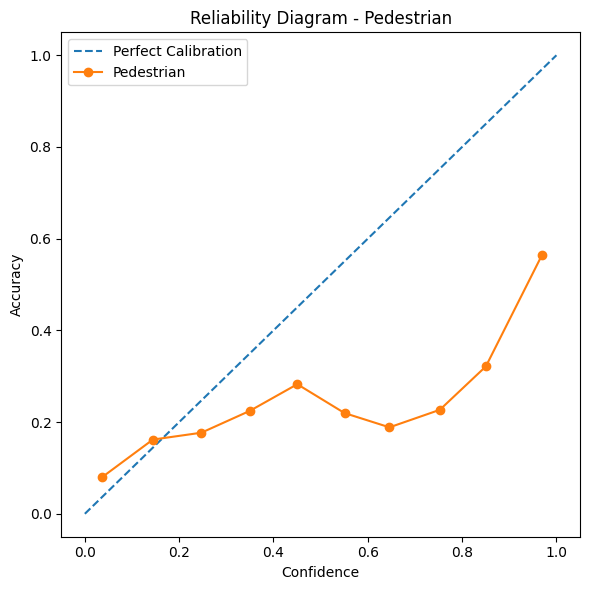

ECE = 0.1670

Evaluating Vehicle


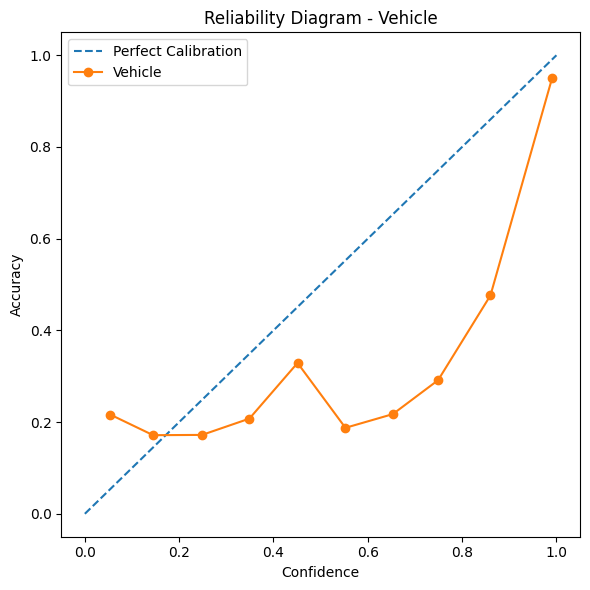

ECE = 0.1152

Evaluating Traffic Light


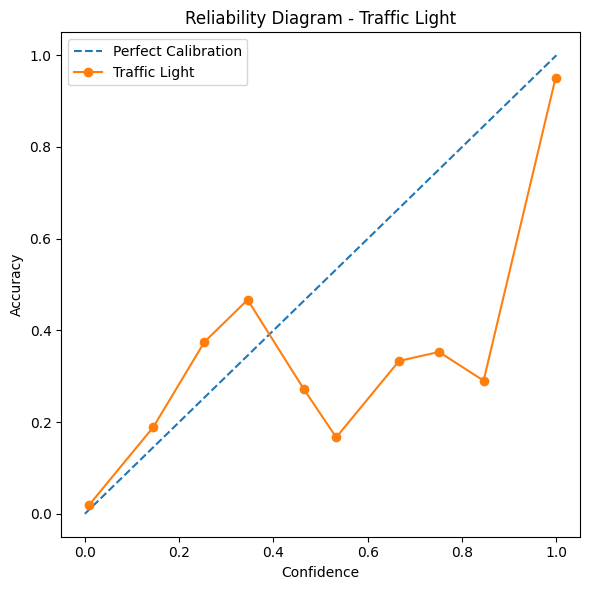

ECE = 0.0482


In [28]:
results = []

models_info = [

    (
        "Pedestrian",
        "../models/pedestrian_model.pth",
        "has_pedestrian"
    ),

    (
        "Vehicle",
        "../models/vehicle_model.pth",
        "has_vehicle"
    ),

    (
        "Traffic Light",
        "../models/traffic_light_model.pth",
        "has_traffic_light"
    )
]

for model_name, model_path, target in models_info:

    print(
        f"\nEvaluating {model_name}"
    )

    dataset = CarlaDataset(

        test_df,

        "../datasets/test/rgb-front",

        target
    )

    loader = DataLoader(

        dataset,

        batch_size=64,

        shuffle=False
    )

    model = load_model(
        model_path
    )

    probabilities, labels = get_probabilities(
        model,
        loader
    )

    ece = compute_ece(
        probabilities,
        labels
    )

    reliability_diagram(
        probabilities,
        labels,
        model_name
    )

    results.append(
        [
            model_name,
            ece
        ]
    )

    print(
        f"ECE = {ece:.4f}"
    )

In [29]:
ece_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "ECE"
    ]
)

ece_df.to_csv(

    "../results/excercise_9/exercise9_ece.csv",

    index=False
)

ece_df

,Model,ECE
0,Pedestrian,0.167001
1,Vehicle,0.115243
2,Traffic Light,0.048179


In [30]:
#9.5 Temperature Scaling
# Collect logits and labels

def get_logits_and_labels(
    model,
    dataloader
):

    all_logits = []

    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)

            outputs = model(images)

            all_logits.extend(
                outputs.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy()
            )

    return (
        np.array(all_logits),
        np.array(all_labels)
    )

In [31]:
# Compute NLL for a given temperature

def compute_nll(
    logits,
    labels,
    temperature
):

    scaled_logits = logits / temperature

    logits_tensor = torch.tensor(
        scaled_logits,
        dtype=torch.float32
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.float32
    )

    criterion = nn.BCEWithLogitsLoss()

    loss = criterion(
        logits_tensor,
        labels_tensor
    )

    return loss.item()

In [32]:
# Search T from 0.5 to 3.0

def find_best_temperature(
    logits,
    labels
):

    temperatures = np.arange(
        0.5,
        3.1,
        0.1
    )

    nll_values = []

    best_T = None

    best_nll = float("inf")

    for T in temperatures:

        nll = compute_nll(
            logits,
            labels,
            T
        )

        nll_values.append(
            nll
        )

        if nll < best_nll:

            best_nll = nll

            best_T = T

    return (
        best_T,
        temperatures,
        nll_values
    )

In [33]:
# Compute ECE after scaling

def compute_scaled_ece(
    logits,
    labels,
    temperature
):

    scaled_logits = logits / temperature

    probabilities = torch.sigmoid(

        torch.tensor(
            scaled_logits,
            dtype=torch.float32
        )

    ).numpy()

    return compute_ece(
        probabilities,
        labels
    )

In [37]:
# Plot NLL vs Temperature

def plot_temperature_curve(
    temperatures,
    nll_values,
    model_name
):

    plt.figure(
        figsize=(6,4)
    )

    plt.plot(
        temperatures,
        nll_values,
        marker="o"
    )

    plt.xlabel(
        "Temperature T"
    )

    plt.ylabel(
        "Validation NLL"
    )

    plt.title(
        f"Temperature Scaling - {model_name}"
    )

    plt.tight_layout()

    plt.savefig(
        f"../results/excercise_9/{model_name.lower().replace(' ','_')}_temperature_curve.png"
    )

    plt.show()

In [38]:
val_df = pd.read_csv(
    "../datasets/validation/labels.csv"
)

test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)


Processing Pedestrian


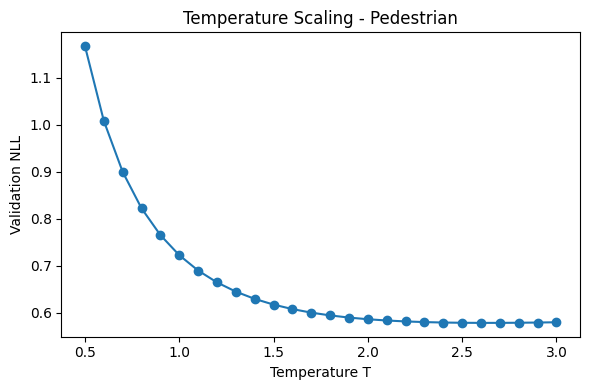

Best T = 2.60
ECE Before = 0.1670
ECE After = 0.2048

Processing Vehicle


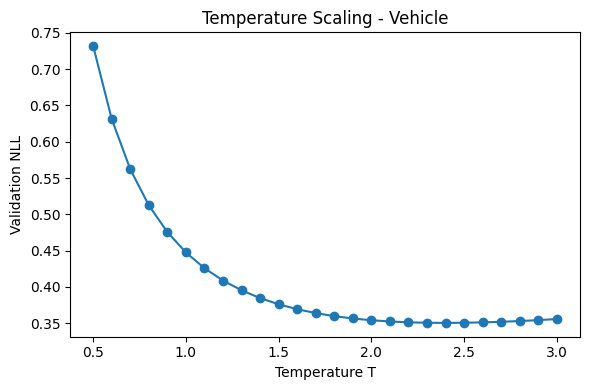

Best T = 2.40
ECE Before = 0.1152
ECE After = 0.0912

Processing Traffic Light


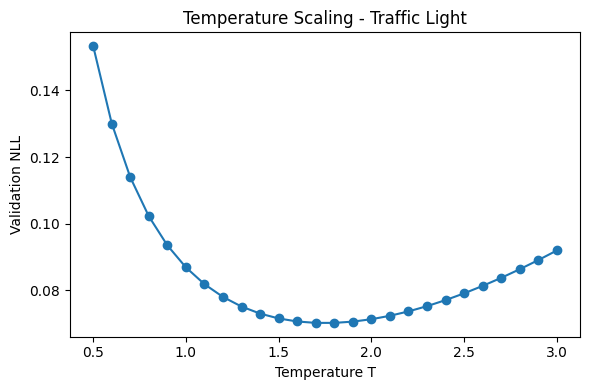

Best T = 1.70
ECE Before = 0.0482
ECE After = 0.0415


In [39]:
temperature_results = []

models_info = [

    (
        "Pedestrian",
        "../models/pedestrian_model.pth",
        "has_pedestrian",
        0.167001
    ),

    (
        "Vehicle",
        "../models/vehicle_model.pth",
        "has_vehicle",
        0.115243
    ),

    (
        "Traffic Light",
        "../models/traffic_light_model.pth",
        "has_traffic_light",
        0.048179
    )
]

for model_name, model_path, target, ece_before in models_info:

    print(f"\nProcessing {model_name}")

    model = load_model(
        model_path
    )

    # Validation set

    val_dataset = CarlaDataset(

        val_df,

        "../datasets/validation/rgb-front",

        target
    )

    val_loader = DataLoader(

        val_dataset,

        batch_size=64,

        shuffle=False
    )

    val_logits, val_labels = get_logits_and_labels(

        model,

        val_loader
    )

    best_T, temps, nlls = find_best_temperature(

        val_logits,

        val_labels
    )

    plot_temperature_curve(

        temps,

        nlls,

        model_name
    )

    # Test set

    test_dataset = CarlaDataset(

        test_df,

        "../datasets/test/rgb-front",

        target
    )

    test_loader = DataLoader(

        test_dataset,

        batch_size=64,

        shuffle=False
    )

    test_logits, test_labels = get_logits_and_labels(

        model,

        test_loader
    )

    ece_after = compute_scaled_ece(

        test_logits,

        test_labels,

        best_T
    )

    temperature_results.append(

        [
            model_name,
            best_T,
            ece_before,
            ece_after
        ]
    )

    print(
        f"Best T = {best_T:.2f}"
    )

    print(
        f"ECE Before = {ece_before:.4f}"
    )

    print(
        f"ECE After = {ece_after:.4f}"
    )

In [40]:
temperature_df = pd.DataFrame(

    temperature_results,

    columns=[

        "Model",

        "Best_T",

        "ECE_Before",

        "ECE_After"
    ]
)

temperature_df.to_csv(

    "../results/excercise_9/exercise9_temperature_scaling.csv",

    index=False
)

temperature_df

,Model,Best_T,ECE_Before,ECE_After
0,Pedestrian,2.6,0.167001,0.204846
1,Vehicle,2.4,0.115243,0.091227
2,Traffic Light,1.7,0.048179,0.041455


In [5]:
#Exercise 9.6
# Cost values from Exercise 9.3 required for this question

CFN = 100
CFP = 1

# Standard classification threshold

TAU_STANDARD = 0.5

# Cost-optimal threshold derived in Exercise 9.3

TAU_STAR = 1 / 101

# Best temperature obtained in Exercise 9.5
# Replace if your final value differs

BEST_T = 2.6

print("tau* =", TAU_STAR)

tau* = 0.009900990099009901


In [6]:
# Load the in-distribution test set

test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)

pedestrian_test = CarlaDataset(

    test_df,

    "../datasets/test/rgb-front",

    "has_pedestrian"
)

test_loader = DataLoader(

    pedestrian_test,

    batch_size=64,

    shuffle=False
)

print(
    "Test samples:",
    len(pedestrian_test)
)

Test samples: 3600


In [7]:
# Load the trained pedestrian classifier

model = load_model(
    "../models/pedestrian_model.pth"
)

# Store raw logits and labels
# We need logits because temperature scaling operates on logits

all_logits = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        all_logits.extend(
            outputs.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy()
        )

all_logits = np.array(all_logits)

all_labels = np.array(all_labels)

print(
    "Collected logits:",
    len(all_logits)
)

Collected logits: 3600


In [15]:
from sklearn.metrics import confusion_matrix

In [16]:
# Computes:
# L = CFN * FN + CFP * FP for a given threshold

def compute_total_loss(
    probabilities,
    labels,
    threshold
):

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions
    ).ravel()

    total_loss = (
        CFN * fn
        +
        CFP * fp
    )

    return {

        "FN": fn,

        "FP": fp,

        "Loss": total_loss
    }

In [17]:
# Uncalibrated probabilities
# Direct sigmoid on logits

uncalibrated_probs = torch.sigmoid(

    torch.tensor(
        all_logits,
        dtype=torch.float32
    )

).numpy()

# Calibrated probabilities
# Apply temperature scaling first

calibrated_probs = torch.sigmoid(

    torch.tensor(

        all_logits / BEST_T,

        dtype=torch.float32

    )

).numpy()

In [18]:
# Question 1
# Uncalibrated model

uncal_tau05 = compute_total_loss(

    uncalibrated_probs,

    all_labels,

    TAU_STANDARD
)

uncal_taustar = compute_total_loss(

    uncalibrated_probs,

    all_labels,

    TAU_STAR
)

# Question 2
# Temperature-scaled model

cal_tau05 = compute_total_loss(

    calibrated_probs,

    all_labels,

    TAU_STANDARD
)

cal_taustar = compute_total_loss(

    calibrated_probs,

    all_labels,

    TAU_STAR
)

In [19]:
# Assignment asks for:
# Rows:
# Uncalibrated
# Calibrated
# Columns:
# tau = 0.5
# tau = tau*

loss_table = pd.DataFrame({

    "tau = 0.5": [

        uncal_tau05["Loss"],

        cal_tau05["Loss"]
    ],

    "tau = tau*": [

        uncal_taustar["Loss"],

        cal_taustar["Loss"]
    ]

},

index=[

    "Uncalibrated",

    "Calibrated"
])

loss_table

,tau = 0.5,tau = tau*
Uncalibrated,35275,3915
Calibrated,35275,2894


In [20]:
detailed_results = pd.DataFrame([

    [

        "Uncalibrated",

        "0.5",

        uncal_tau05["FN"],

        uncal_tau05["FP"],

        uncal_tau05["Loss"]

    ],

    [

        "Uncalibrated",

        "tau*",

        uncal_taustar["FN"],

        uncal_taustar["FP"],

        uncal_taustar["Loss"]

    ],

    [

        "Calibrated",

        "0.5",

        cal_tau05["FN"],

        cal_tau05["FP"],

        cal_tau05["Loss"]

    ],

    [

        "Calibrated",

        "tau*",

        cal_taustar["FN"],

        cal_taustar["FP"],

        cal_taustar["Loss"]

    ]

],

columns=[

    "Model",

    "Threshold",

    "FN",

    "FP",

    "Total Loss"
])

detailed_results

,Model,Threshold,FN,FP,Total Loss
0,Uncalibrated,0.5,346,675,35275
1,Uncalibrated,tau*,13,2615,3915
2,Calibrated,0.5,346,675,35275
3,Calibrated,tau*,0,2894,2894


In [21]:
loss_table.to_csv(

    "../results/excercise_9/exercise9_cost_optimal_table.csv"
)

detailed_results.to_csv(

    "../results/excercise_9/exercise9_cost_optimal_details.csv",

    index=False
)